## STEP 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
print("Libraries Imported Successfully")

Libraries Imported Successfully


## STEP 2 — Load Cleaned Dataset

In [2]:
df = pd.read_csv(
    "D:/Thiranex/cleaned_data/cleaned_netflix_dataset.csv"
)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


## STEP 3 — Dataset Overview

In [3]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

Shape of Dataset:
(8807, 13)

Columns:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8807 non-null   object 
 1   type          8807 non-null   object 
 2   title         8807 non-null   object 
 3   director      8807 non-null   object 
 4   cast          8807 non-null   object 
 5   country       8807 non-null   object 
 6   date_added    8709 non-null   object 
 7   release_year  8807 non-null   int64  
 8   rating        8807 non-null   object 
 9   duration      8804 non-null   object 
 10  listed_in     8807 non-null   object 
 11  description   8807 non-null   object 
 12  year_added    8709 non-null 

## STEP 4 — Statistical Summary

In [4]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
count,8807,8807,8807,8807,8807,8807,8709,8807.000000,8807,8804,8807,8807,8709.000000
unique,8807,2,8807,4529,7693,749,1699,NaN,17,220,514,8775,NaN
top,s8807,Movie,Zubaan,Unknown,Unknown,United States,2020-01-01,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",NaN
freq,1,6131,1,2634,825,2818,109,NaN,3211,1793,362,4,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN,2018.887932
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN,1.567961
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN,2008.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN,2018.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN,2019.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN,2020.000000


## STEP 5 — Correlation Analysis

In [5]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(
            df_encoded[col].astype(str)
        )

## STEP 6 — Correlation Heatmap

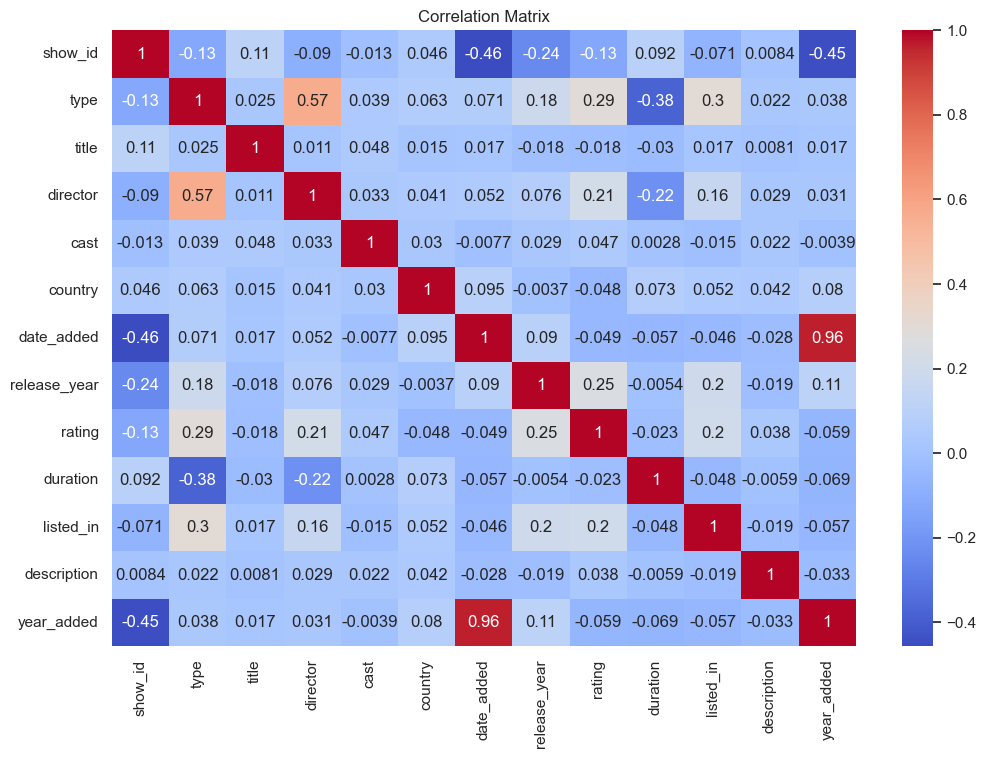

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

## STEP 7 — Movies vs TV Shows

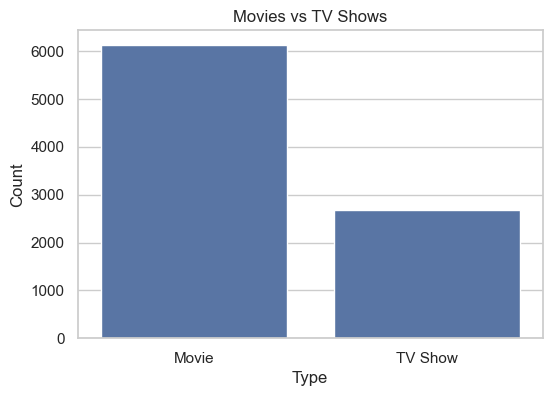

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='type',
    data=df
)
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

## STEP 8 — Netflix Content Growth

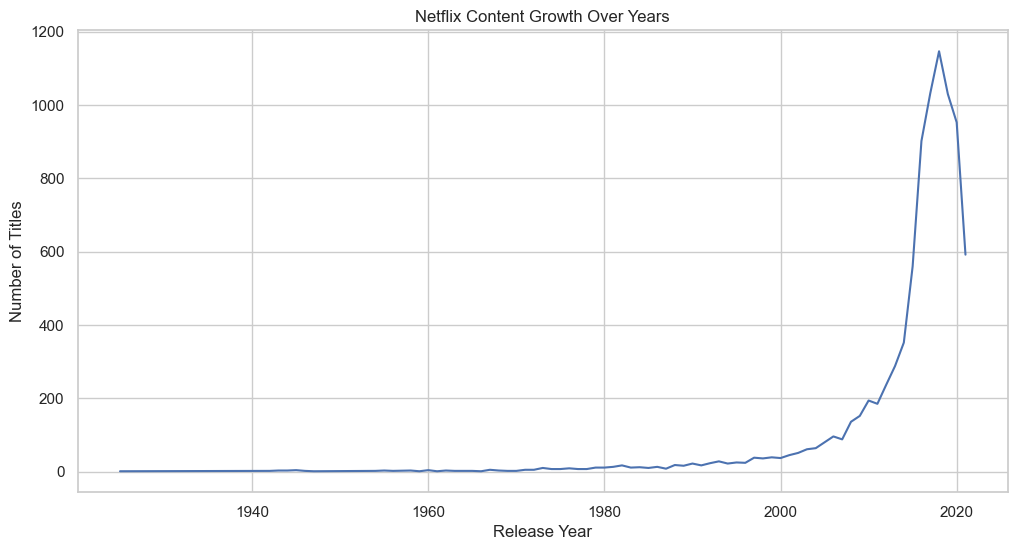

In [8]:
plt.figure(figsize=(12,6))
df['release_year'].value_counts().sort_index().plot()
plt.title("Netflix Content Growth Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

## STEP 9 — Top 10 Countries

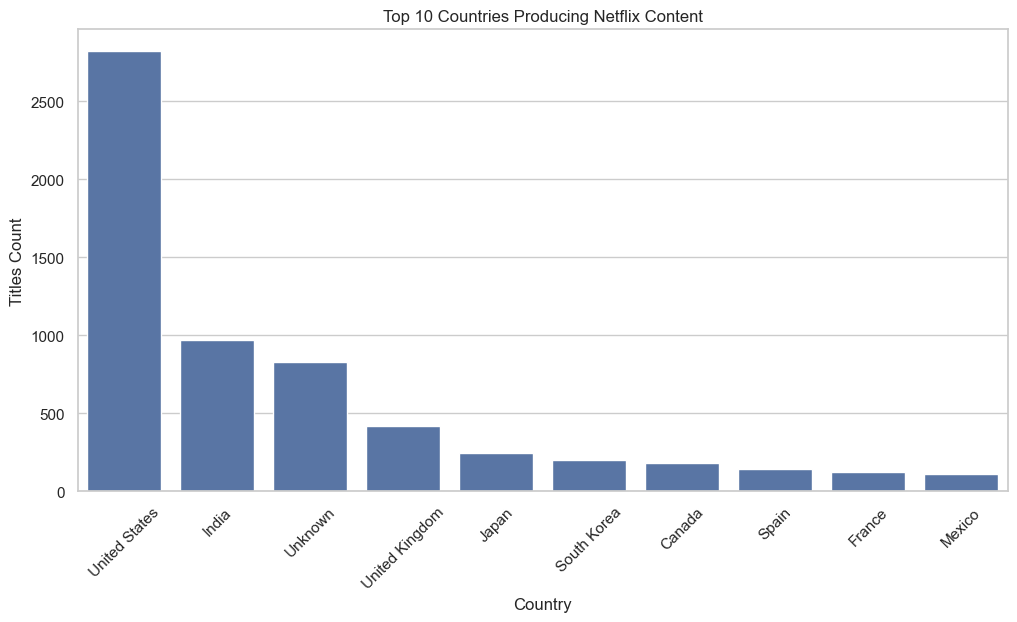

In [9]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)
plt.xticks(rotation=45)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Titles Count")
plt.show()

## STEP 10 — Ratings Distribution

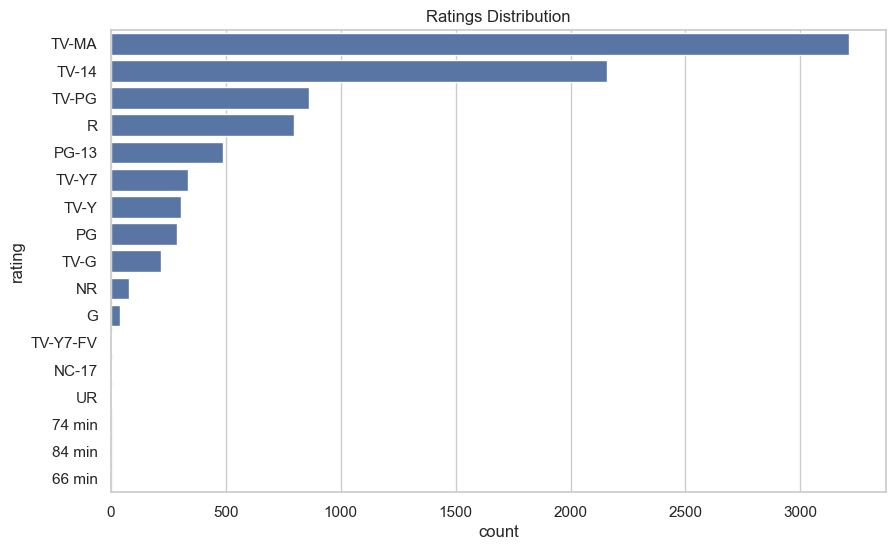

In [10]:
plt.figure(figsize=(10,6))
sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)
plt.title("Ratings Distribution")
plt.show()

## STEP 11 — Top Directors

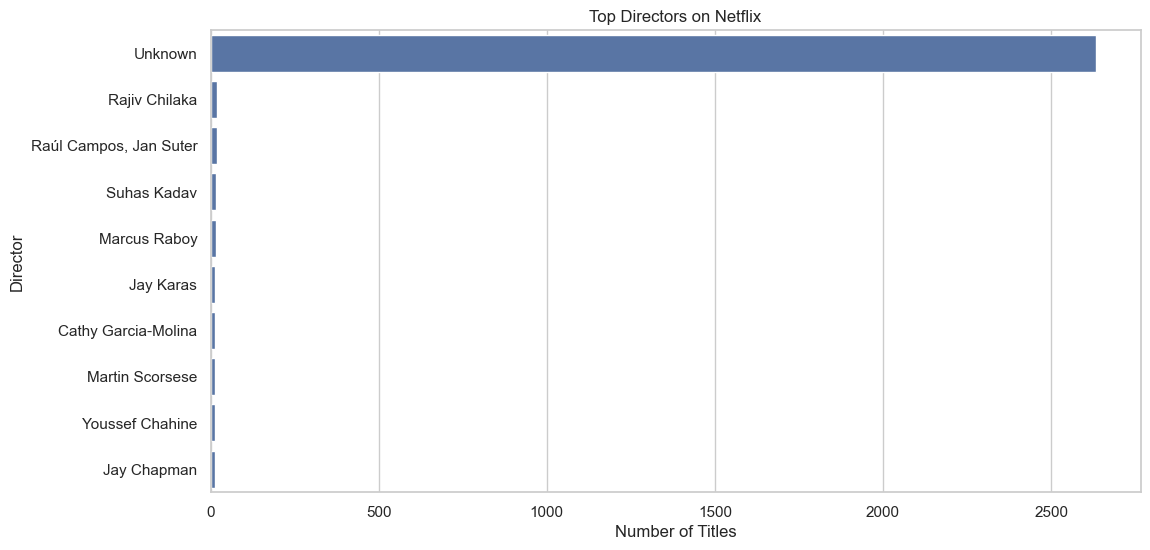

In [11]:
top_directors = df['director'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)
plt.title("Top Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()

## STEP 12 — Content Added Per Year

In [12]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)
df['year_added'] = df['date_added'].dt.year

## Visualization

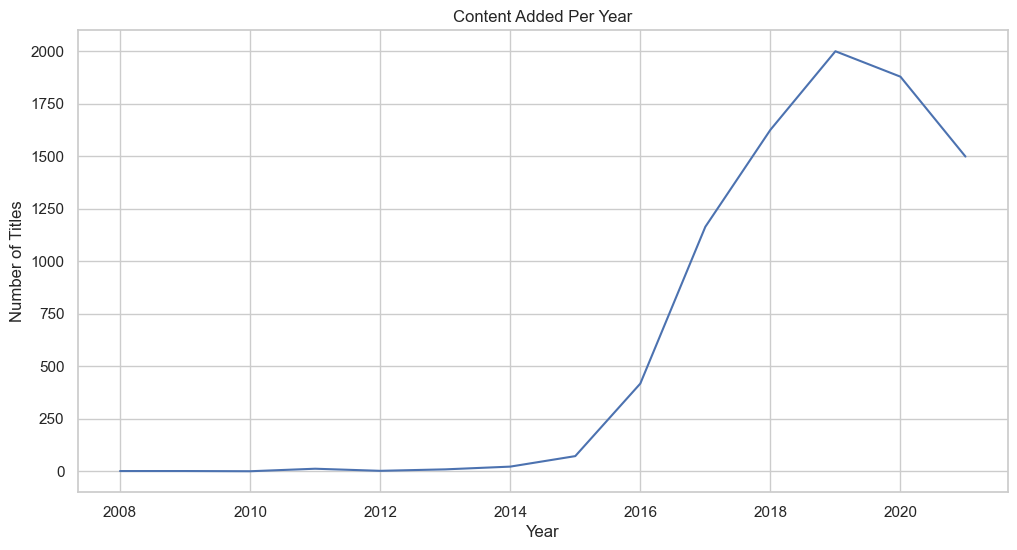

In [13]:
plt.figure(figsize=(12,6))
df['year_added'].value_counts().sort_index().plot()
plt.title("Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

## STEP 13 — Histogram

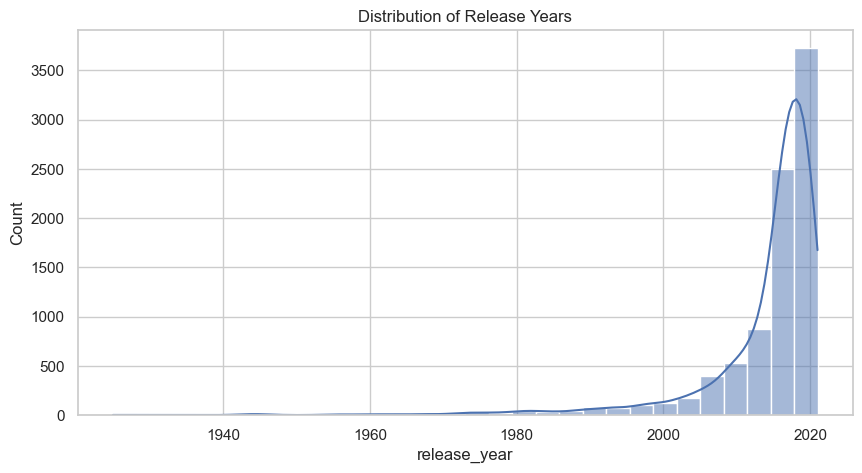

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(
    df['release_year'],
    bins=30,
    kde=True
)
plt.title("Distribution of Release Years")
plt.show()

## STEP 14 — Boxplot

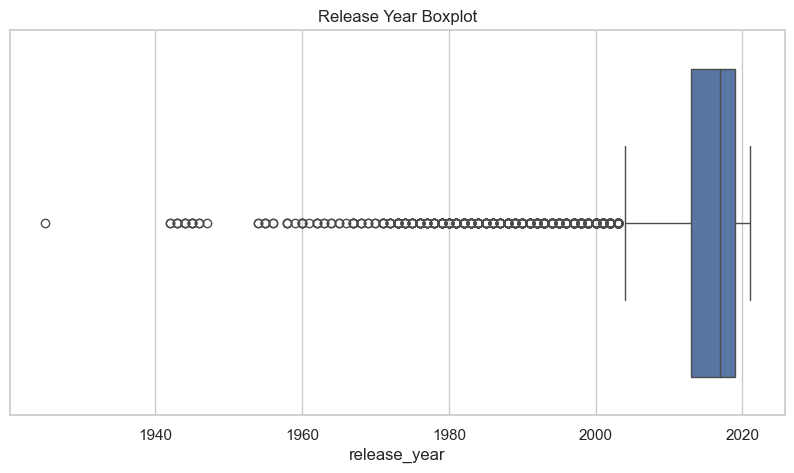

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x=df['release_year']
)
plt.title("Release Year Boxplot")
plt.show()

## STEP 15 — Pairplot

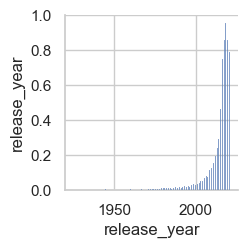

In [16]:
sns.pairplot(
    df_encoded[['release_year']]
)
plt.show()

## STEP 16 — Final Insights

# Key Insights

1. Netflix content increased rapidly after 2015.

2. Movies are more common than TV Shows.

3. The USA contributes the highest amount of content.

4. TV-MA is the most common content rating.

5. Some directors contribute significantly more content than others.

6. Netflix aggressively expanded its content library during recent years.

## STEP 17 — Save EDA Summary

In [17]:
summary = df.describe(include='all')
summary.to_csv(
    "cleaned_data/eda_summary.csv"
)
print("EDA Summary Saved Successfully")

OSError: Cannot save file into a non-existent directory: 'cleaned_data'